In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### DATA Cleaning

#### Why did some passengers survive while others did not?
#### Did gender affect survival?
#### Did passenger class affect survival?
####  Did age affect survival?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [19]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
adult_male       0
embark_town      2
alone            0
dtype: int64

In [17]:

df.drop(columns={'deck','who','alive'},inplace=True)

In [18]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,True


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    object  
 11  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


In [21]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df["age"].fillna(df["age"].median(), inplace=True)

/var/folders/pl/zqvlz4ws5f97jn21xzq7c3qm0000gn/T/ipykernel_5525/3040546416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


In [27]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
adult_male     0
embark_town    2
alone          0
dtype: int64

In [26]:
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

/var/folders/pl/zqvlz4ws5f97jn21xzq7c3qm0000gn/T/ipykernel_5525/3995229981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)


In [28]:
df['embarked'].mode()

0    S
Name: embarked, dtype: object

In [31]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.drop_duplicates(inplace=True)

In [32]:
df.duplicated().sum()


np.int64(0)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    object  
 8   class        775 non-null    category
 9   adult_male   775 non-null    bool    
 10  embark_town  773 non-null    object  
 11  alone        775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 62.9+ KB


In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,True


In [35]:
# Survived
# Pclass
# Sex
# Age
# SibSp
# Parch
# Fare
# Embarked

In [36]:
df.drop(columns={'class','adult_male','embark_town','alone'},inplace=True)

In [38]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')

In [39]:
df.to_csv('cleaned_data.csv')
print("data cleaned")

data cleaned


### feature engi

In [41]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')

In [43]:
df["FamilySize"] = df["sibsp"] + df["parch"] + 1

In [45]:
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[0,12,18,35,60,100],
 
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

In [47]:
df.head(30)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,2,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,2,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,2,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,1,Young Adult
5,0,3,male,28.0,0,0,8.4583,Q,1,Young Adult
6,0,1,male,54.0,0,0,51.8625,S,1,Adult
7,0,3,male,2.0,3,1,21.0750,S,5,Child
8,1,3,female,27.0,0,2,11.1333,S,3,Young Adult
9,1,2,female,14.0,1,0,30.0708,C,2,Teen


In [49]:
df["FareCategory"] = pd.qcut(
    df["fare"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

In [51]:
df.head(30)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,AgeGroup,FareCategory
0,0,3,male,22.0,1,0,7.2500,S,2,Young Adult,Low
1,1,1,female,38.0,1,0,71.2833,C,2,Adult,Very High
2,1,3,female,26.0,0,0,7.9250,S,1,Young Adult,Low
3,1,1,female,35.0,1,0,53.1000,S,2,Young Adult,Very High
4,0,3,male,35.0,0,0,8.0500,S,1,Young Adult,Low
5,0,3,male,28.0,0,0,8.4583,Q,1,Young Adult,Medium
6,0,1,male,54.0,0,0,51.8625,S,1,Adult,Very High
7,0,3,male,2.0,3,1,21.0750,S,5,Child,High
8,1,3,female,27.0,0,2,11.1333,S,3,Young Adult,Medium
9,1,2,female,14.0,1,0,30.0708,C,2,Teen,High


### visualization

In [54]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,AgeGroup,FareCategory
0,0,3,male,22.0,1,0,7.2500,S,2,Young Adult,Low
1,1,1,female,38.0,1,0,71.2833,C,2,Adult,Very High
2,1,3,female,26.0,0,0,7.9250,S,1,Young Adult,Low
3,1,1,female,35.0,1,0,53.1000,S,2,Young Adult,Very High
4,0,3,male,35.0,0,0,8.0500,S,1,Young Adult,Low


<Axes: xlabel='sex', ylabel='count'>

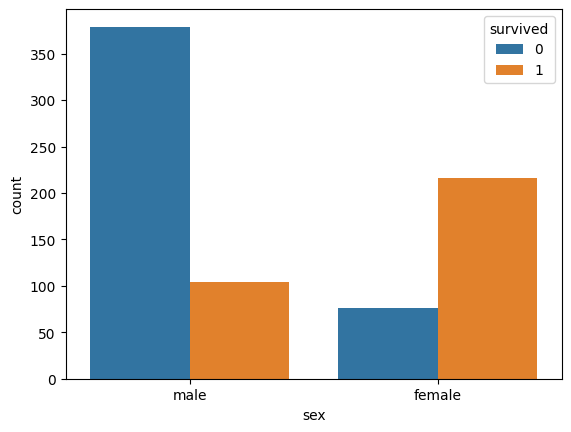

In [55]:
sns.countplot(x="sex", hue="survived", data=df)

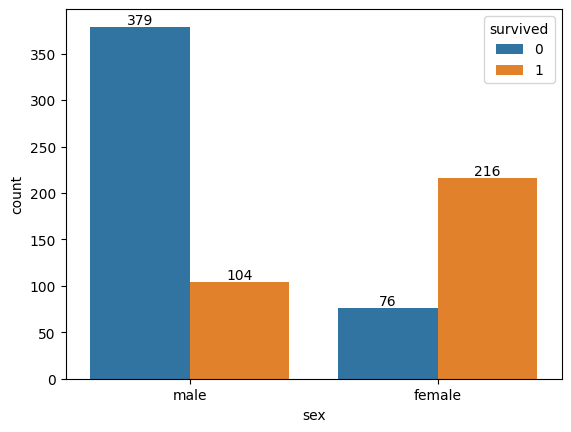

In [57]:
ax = sns.countplot(x='sex',data=df,hue='survived')
for bars in ax.containers:
    ax.bar_label(bars)

In [59]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'FamilySize', 'AgeGroup', 'FareCategory'],
      dtype='object')

<Axes: xlabel='pclass', ylabel='count'>

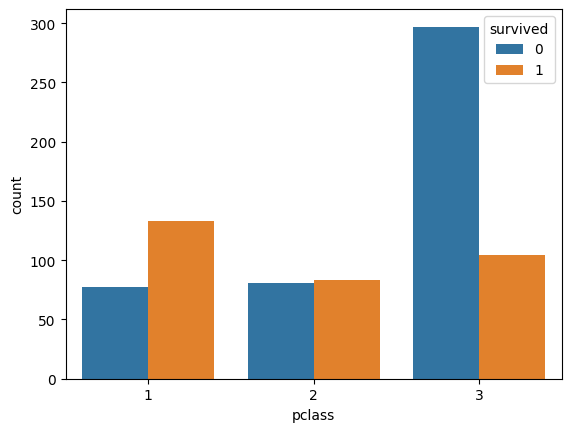

In [60]:
sns.countplot(x="pclass", hue="survived", data=df)

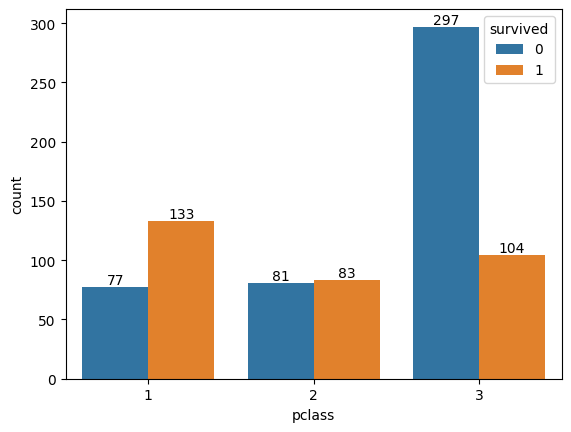

In [61]:
ax = sns.countplot(x='pclass',data=df,hue='survived')
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='age', ylabel='Count'>

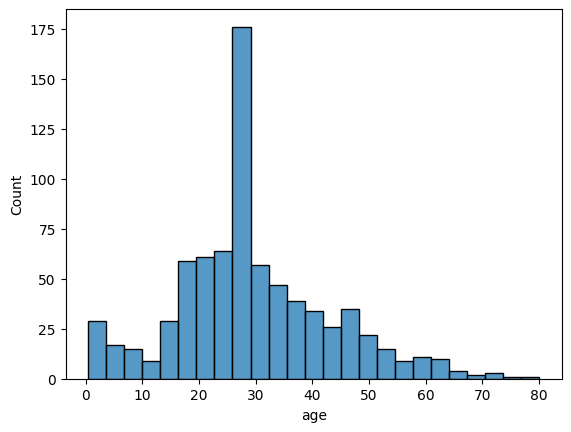

In [62]:
sns.histplot(df["age"])

<Axes: xlabel='AgeGroup', ylabel='count'>

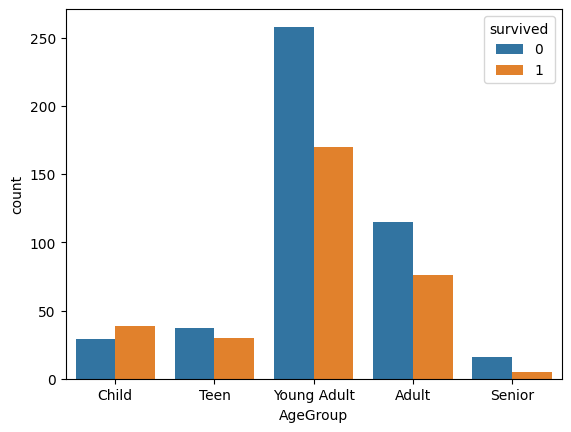

In [63]:
sns.countplot(x="AgeGroup", hue="survived", data=df)

<Axes: xlabel='survived', ylabel='fare'>

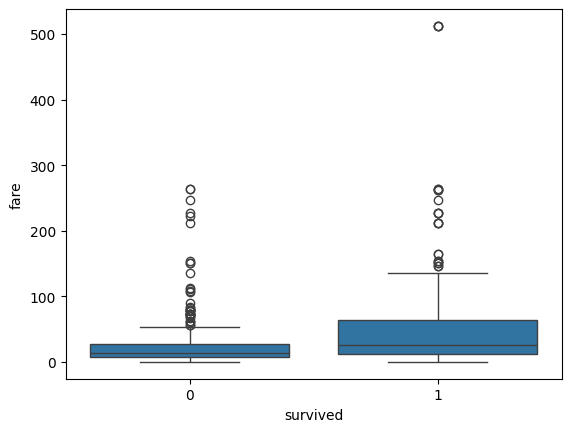

In [64]:
sns.boxplot(x="survived", y="fare", data=df)